In [1]:
import pandas as pd
import numpy as np
import itertools
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score
import os, json

2025-10-31 19:38:43.721296: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
file_path = "data_bersih.csv"  # ganti jika lokasi berbeda
df = pd.read_csv(file_path)

print("Ukuran data:", df.shape)
df.head()

Ukuran data: (35000, 36)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Attack Type
0,-1.956184,-0.060541,0.726679,0.475605,3.497057,0.287432,-0.030221,0.730687,1.572349,-1.502037,...,0.050704,-0.086402,-0.858818,0.030566,-0.203141,0.349786,0.000300,0.115312,-0.044973,Brute Force
1,-1.598745,0.049700,-0.402439,0.215666,-0.422642,0.816454,0.103737,0.640042,-1.222682,-0.477930,...,-0.040110,-0.524495,0.527427,0.801224,0.076679,-0.305894,0.001080,0.000204,0.144445,Bot
2,-1.013630,-0.039427,-0.383487,-0.555417,-0.118540,1.771405,0.177800,0.936981,-2.341776,-0.019136,...,2.048246,0.756987,-0.850397,0.095773,-0.144890,0.255822,-0.000624,-0.096598,-0.326522,Web Attack
3,-1.012685,-0.039528,-0.382807,-0.555544,-0.118419,1.771393,0.177796,0.936887,-2.341814,-0.019007,...,2.048076,0.757052,-0.850358,0.095889,-0.144695,0.255626,-0.000623,-0.096972,-0.326207,Web Attack
4,-1.954417,-0.060487,0.725888,0.473916,3.483966,0.286304,-0.030157,0.728402,1.569341,-1.496205,...,0.052369,-0.084534,-0.857609,0.030317,-0.202095,0.349372,0.000302,0.115583,-0.044602,Brute Force


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PC1          35000 non-null  float64
 1   PC2          35000 non-null  float64
 2   PC3          35000 non-null  float64
 3   PC4          35000 non-null  float64
 4   PC5          35000 non-null  float64
 5   PC6          35000 non-null  float64
 6   PC7          35000 non-null  float64
 7   PC8          35000 non-null  float64
 8   PC9          35000 non-null  float64
 9   PC10         35000 non-null  float64
 10  PC11         35000 non-null  float64
 11  PC12         35000 non-null  float64
 12  PC13         35000 non-null  float64
 13  PC14         35000 non-null  float64
 14  PC15         35000 non-null  float64
 15  PC16         35000 non-null  float64
 16  PC17         35000 non-null  float64
 17  PC18         35000 non-null  float64
 18  PC19         35000 non-null  float64
 19  PC20

In [5]:
X = df.drop(columns=['Attack Type']).copy()
y = df['Attack Type'].copy()

# Encode target jika berupa kategori
if y.dtype == 'object' or y.dtype.name == 'category':
    lbl_enc = LabelEncoder()
    y = lbl_enc.fit_transform(y)
    target_type = 'classification'
else:
    # cek apakah target diskrit
    unique_y = np.unique(y)
    if len(unique_y) <= 10 and np.all(np.mod(unique_y, 1) == 0):
        # target diskrit dengan sedikit kelas => perlakukan sebagai klasifikasi
        lbl_enc = LabelEncoder()
        y = lbl_enc.fit_transform(y)
        target_type = 'classification'
    else:
        target_type = 'regression'

print("Tipe target:", target_type)
print("Jumlah kelas unik" if target_type=='classification' else "Contoh nilai target:", 
      len(np.unique(y)) if target_type=='classification' else unique_y[:5])

Tipe target: classification
Jumlah kelas unik 7


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
def create_dnn_model(input_dim, hidden_layers, activation, learning_rate, target_type):
    model = Sequential()

    for i, units in enumerate(hidden_layers):
        if i == 0:
            model.add(Dense(units, input_dim=input_dim))
        else:
            model.add(Dense(units))

        # Atur aktivasi
        if activation == 'leaky_relu':
            model.add(LeakyReLU(alpha=0.1))
        else:
            model.add(tf.keras.layers.Activation(activation))

    # Output layer
    if target_type == 'classification':
        # asumsikan multi-class
        num_classes = len(np.unique(y_train))  # y_train akan didefinisikan kemudian
        if num_classes == 2:
            model.add(Dense(1, activation='sigmoid'))
            loss = 'binary_crossentropy'
            metrics = ['accuracy']
        else:
            model.add(Dense(num_classes, activation='softmax'))
            loss = 'sparse_categorical_crossentropy'
            metrics = ['accuracy']
    else:
        model.add(Dense(1, activation='linear'))
        loss = 'mse'
        metrics = ['mse']

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model

In [8]:
default_params = {
    'split': 0.2,               # artinya train:test = 80:20
    'hidden_layers': [100],
    'activation': 'relu',
    'epochs': 50,
    'learning_rate': 0.001,
    'batch_size': 32
}

# Variasi parameter per batch sesuai tabel
batch_variations = {
    'split': [0.3, 0.2, 0.1],  # representasi test_size -> 70:30, 80:20, 90:10
    'hidden_layers': [
        [50], [100], [150], [200],
        [100,100], [150,150], [200,200], [250,250], [300,300],
        [100,100,100], [150,150,150], [200,200,200]
    ],
    'activation': ['tanh', 'relu', 'leaky_relu'],
    'epochs': [30, 50, 100, 200],
    'learning_rate': [0.001, 0.003, 0.005, 0.007, 0.009, 0.01],
    'batch_size': [16, 32, 64, 128, 256]
}

# urutan batch (kunci harus sama dengan default_params)
batch_order = ['split', 'hidden_layers', 'activation', 'epochs', 'learning_rate', 'batch_size']

In [9]:
def train_and_evaluate(params, verbose=0, random_state=42):
    test_size = params['split']
    hidden_layers = params['hidden_layers']
    activation = params['activation']
    epochs = params['epochs']
    learning_rate = params['learning_rate']
    batch_size = params['batch_size']

    # Split data
    X_train, X_test, y_train_local, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=random_state, stratify=y if target_type=='classification' else None
    )

    global y_train  # agar bisa dipakai di create_dnn_model
    y_train = y_train_local  # update global variable

    # Buat model
    model = create_dnn_model(
        input_dim=X_train.shape[1],
        hidden_layers=hidden_layers,
        activation=activation,
        learning_rate=learning_rate,
        target_type=target_type
    )

    # Early stopping opsional
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks
    )

    # Evaluasi
    y_pred = model.predict(X_test, verbose=0)

    if target_type == 'classification':
        num_classes = len(np.unique(y_train))
        if num_classes == 2:
            y_pred_label = (y_pred.ravel() >= 0.5).astype(int)
        else:
            y_pred_label = np.argmax(y_pred, axis=1)

        acc = accuracy_score(y_test, y_pred_label)
        f1 = f1_score(y_test, y_pred_label, average='weighted')
        primary_metric = acc  # bisa juga f1
        metrics = {
            'accuracy': acc,
            'f1_score': f1
        }
    else:
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        primary_metric = -mse  # karena kita ingin nilai mse kecil, kita invers
        metrics = {
            'mse': mse,
            'r2': r2
        }

    return model, metrics, primary_metric, history.history

In [10]:
results_log = {}
best_params = default_params.copy()
best_models = {}

print("Parameter default awal:", best_params)

for batch_name in batch_order:
    print("\n=== Batch: {} ===".format(batch_name))

    variations = batch_variations[batch_name]
    batch_results = []

    for value in variations:
        temp_params = best_params.copy()
        temp_params[batch_name] = value

        print(f"  -> Uji {batch_name} = {value}")

        model, metrics, primary_metric, history = train_and_evaluate(temp_params, verbose=0)
        batch_results.append({
            'param_value': value,
            'metrics': metrics,
            'primary_metric': primary_metric,
            'history': history,
            'params': temp_params,
            'model': model
        })

    # Pilih yang terbaik
    if target_type == 'classification':
        best_result = max(batch_results, key=lambda x: x['primary_metric'])
    else:
        best_result = max(batch_results, key=lambda x: x['primary_metric'])  # karena primary_metric = -MSE

    best_value = best_result['param_value']
    best_params = best_result['params']
    best_models[batch_name] = best_result['model']

    # Simpan log
    results_log[batch_name] = {
        'tested': [
            {
                'value': res['param_value'],
                'metrics': res['metrics'],
                'primary_metric': res['primary_metric']
            }
            for res in batch_results
        ],
        'best_value': best_value,
        'best_metrics': best_result['metrics']
    }

    print(f"  -> Terbaik {batch_name}: {best_value}")
    print(f"     Metrics: {best_result['metrics']}")

print("\nParameter terbaik final:", best_params)

Parameter default awal: {'split': 0.2, 'hidden_layers': [100], 'activation': 'relu', 'epochs': 50, 'learning_rate': 0.001, 'batch_size': 32}

=== Batch: split ===
  -> Uji split = 0.3


/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1761939680.543779    1117 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13764 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2025-10-31 19:41:26.165804: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fb5a00079f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-31 19:41:26.165844: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-10-31 19:41:26.580354: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir

  -> Uji split = 0.2


/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  -> Uji split = 0.1


...

  -> Uji batch_size = 128


/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  -> Uji batch_size = 256


/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  -> Terbaik batch_size: 16
     Metrics: {'accuracy': 0.9994285714285714, 'f1_score': 0.9994285708571423}

Parameter terbaik final: {'split': 0.1, 'hidden_layers': [50], 'activation': 'tanh', 'epochs': 100, 'learning_rate': 0.001, 'batch_size': 16}


In [14]:
if target_type != 'classification':
    raise ValueError("Perbandingan akurasi hanya untuk klasifikasi.")

records = []
for batch in batch_order:
    data = results_log.get(batch)
    if data and 'accuracy' in data['best_metrics']:
        records.append({
            'Batch Parameter': batch.replace('_', ' ').title(),
            'Akurasi Terbaik': data['best_metrics']['accuracy']
        })

df_perbandingan = pd.DataFrame(records)
display(df_perbandingan)

,Batch Parameter,Akurasi Terbaik
0,Split,0.999429
1,Hidden Layers,0.999714
2,Activation,0.999429
3,Epochs,0.999714
4,Learning Rate,0.999429
5,Batch Size,0.999429


In [15]:
if target_type != 'classification':
    raise ValueError("Perbandingan akurasi hanya untuk klasifikasi.")

records = []
selected_values = {}

for batch in batch_order:
    batch_info = results_log.get(batch)
    if not batch_info:
        continue

    for test in batch_info['tested']:
        combo = default_params.copy()
        combo.update(selected_values)
        combo[batch] = test['value']

        records.append({
            'Split': combo['split'],
            'Hidden Layers': combo['hidden_layers'],
            'Activation': combo['activation'],
            'Epochs': combo['epochs'],
            'Learning Rate': combo['learning_rate'],
            'Batch Size': combo['batch_size'],
            'Accuracy': test['metrics'].get('accuracy')
        })

    selected_values[batch] = batch_info['best_value']

df_kombinasi = pd.DataFrame(records)
display(df_kombinasi)

,Split,Hidden Layers,Activation,Epochs,Learning Rate,Batch Size,Accuracy
0,0.3,[100],relu,50,0.001,32,0.999238
1,0.2,[100],relu,50,0.001,32,0.998000
2,0.1,[100],relu,50,0.001,32,0.999429
3,0.1,[50],relu,50,0.001,32,0.999714
4,0.1,[100],relu,50,0.001,32,0.999143
5,0.1,[150],relu,50,0.001,32,0.999429
6,0.1,[200],relu,50,0.001,32,0.999143
7,0.1,"[100, 100]",relu,50,0.001,32,0.998857
8,0.1,"[150, 150]",relu,50,0.001,32,0.999429
9,0.1,"[200, 200]",relu,50,0.001,32,0.999429


/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first

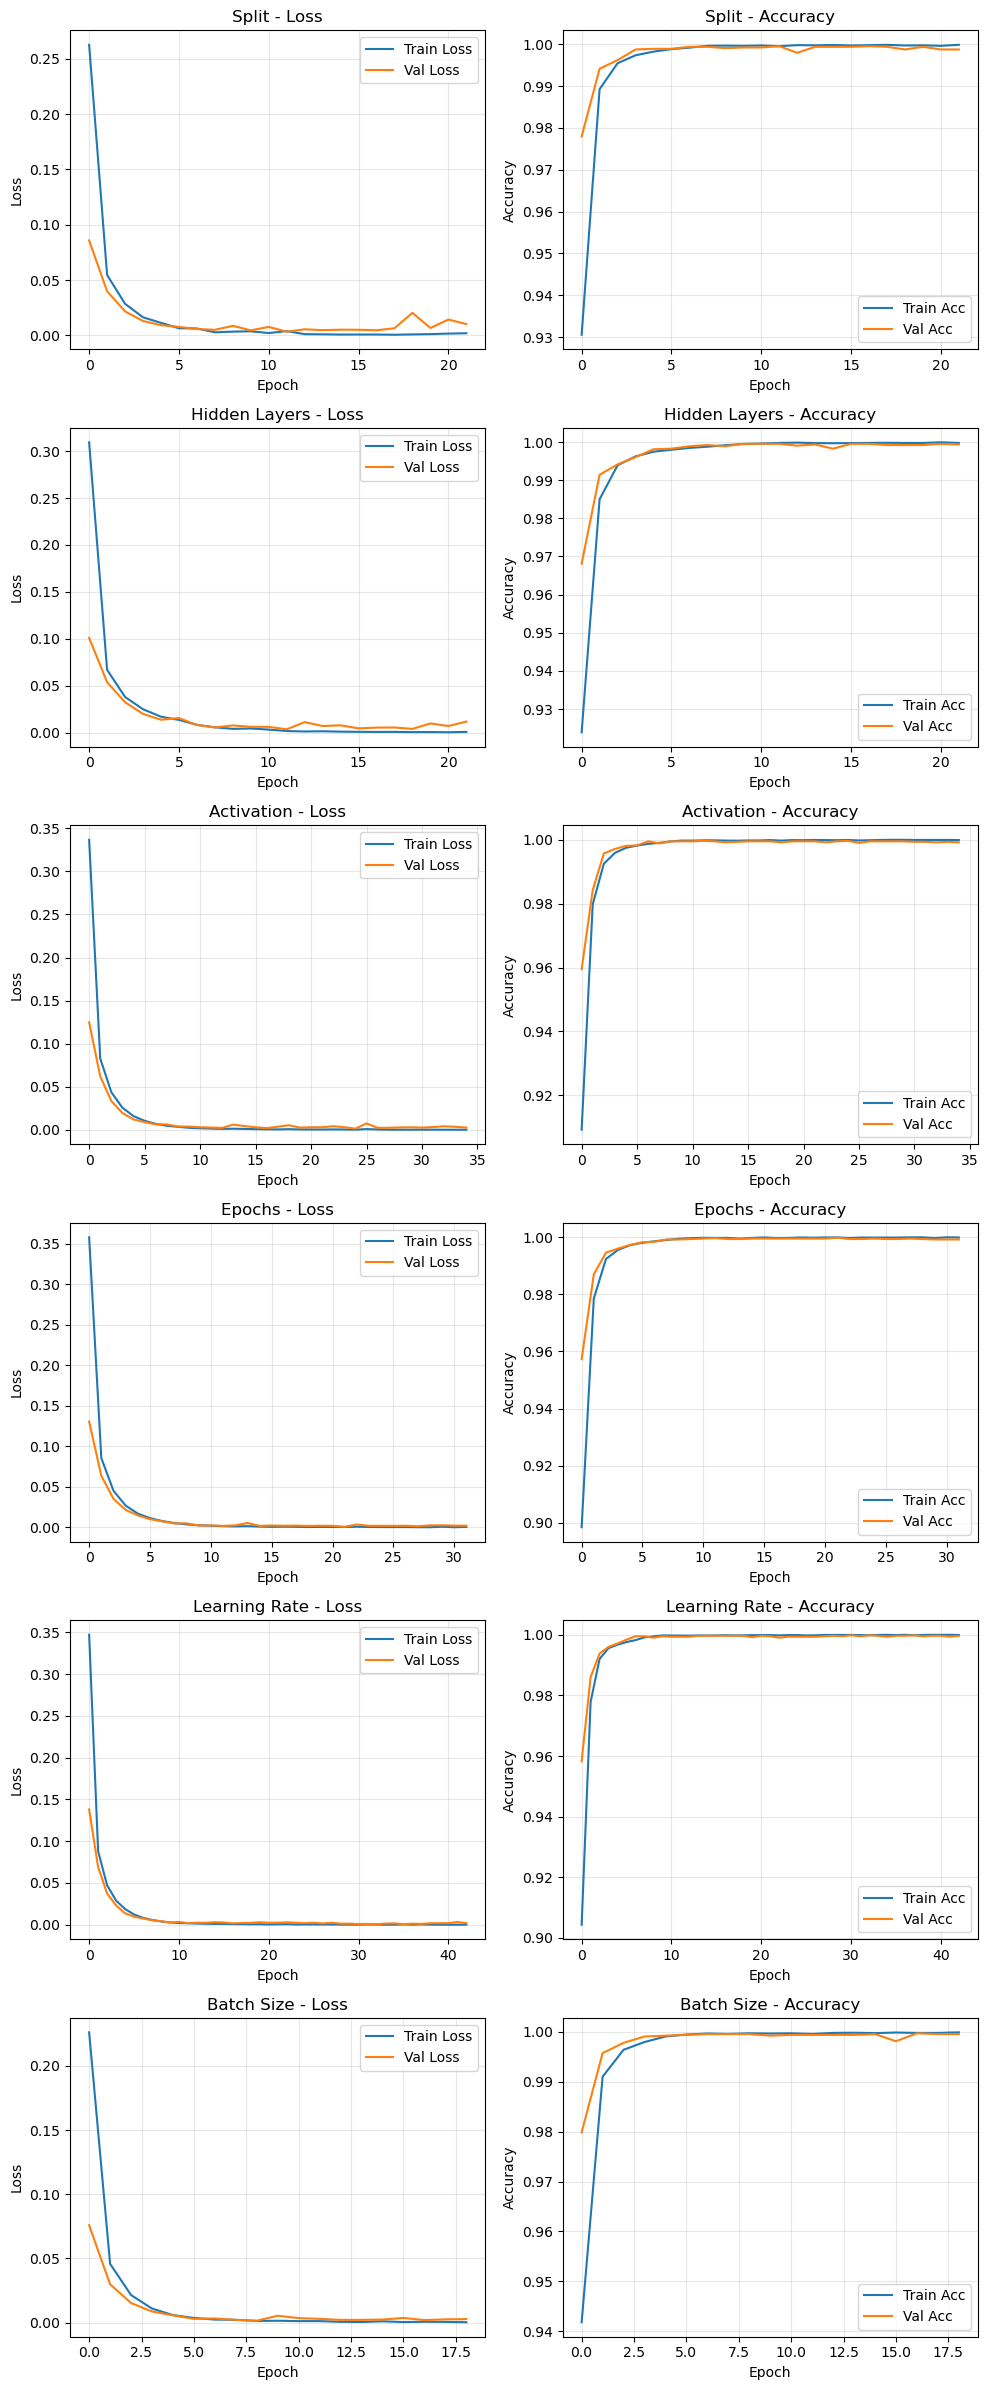

In [16]:
if target_type != 'classification':
    raise ValueError("Grafik akurasi hanya berlaku untuk klasifikasi.")

history_per_batch = {}
cumulative_params = default_params.copy()

for batch in batch_order:
    if batch not in results_log:
        continue
    cumulative_params[batch] = results_log[batch]['best_value']
    model, _, _, history = train_and_evaluate(cumulative_params, verbose=0)
    history_per_batch[batch] = history

n_batches = len(history_per_batch)
fig, axes = plt.subplots(n_batches, 2, figsize=(10, 4 * n_batches), squeeze=False)

for idx, (batch, history) in enumerate(history_per_batch.items()):
    batch_title = batch.replace('_', ' ').title()

    axes[idx, 0].plot(history['loss'], label='Train Loss')
    axes[idx, 0].plot(history['val_loss'], label='Val Loss')
    axes[idx, 0].set_title(f'{batch_title} - Loss')
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].legend()
    axes[idx, 0].grid(alpha=0.3)

    if 'accuracy' in history:
        axes[idx, 1].plot(history['accuracy'], label='Train Acc')
        axes[idx, 1].plot(history['val_accuracy'], label='Val Acc')
        axes[idx, 1].set_title(f'{batch_title} - Accuracy')
        axes[idx, 1].set_xlabel('Epoch')
        axes[idx, 1].set_ylabel('Accuracy')
        axes[idx, 1].legend()
        axes[idx, 1].grid(alpha=0.3)
    else:
        axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


              precision    recall  f1-score   support

      BENIGN   1.000000  1.000000  1.000000       500
         Bot   1.000000  1.000000  1.000000       500
 Brute Force   1.000000  1.000000  1.000000       500
        DDoS   1.000000  1.000000  1.000000       500
         DoS   1.000000  1.000000  1.000000       500
   Port Scan   1.000000  0.998000  0.998999       500
  Web Attack   0.998004  1.000000  0.999001       500

    accuracy                       0.999714      3500
   macro avg   0.999715  0.999714  0.999714      3500
weighted avg   0.999715  0.999714  0.999714      3500



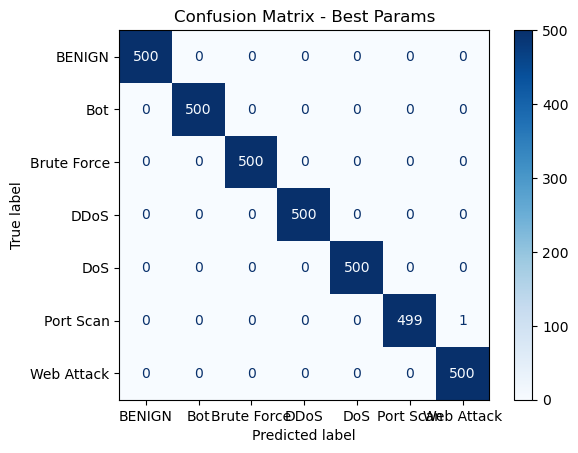

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_params_final = {
    'split': 0.1,
    'hidden_layers': [50],
    'activation': 'tanh',
    'epochs': 100,
    'learning_rate': 0.001,
    'batch_size': 16
}

test_size = best_params_final['split']
X_train, X_test, y_train_final, y_test = train_test_split(
    X_scaled, y,
    test_size=test_size,
    random_state=42,
    stratify=y if target_type == 'classification' else None
)

y_train = y_train_final
model = create_dnn_model(
    input_dim=X_train.shape[1],
    hidden_layers=best_params_final['hidden_layers'],
    activation=best_params_final['activation'],
    learning_rate=best_params_final['learning_rate'],
    target_type=target_type
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=best_params_final['epochs'],
    batch_size=best_params_final['batch_size'],
    verbose=0,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

y_pred_prob = model.predict(X_test, verbose=0)

if target_type == 'classification':
    num_classes = len(np.unique(y_train))
    if num_classes == 2:
        y_pred = (y_pred_prob.ravel() >= 0.5).astype(int)
        target_names = lbl_enc.classes_ if 'lbl_enc' in globals() else None
    else:
        y_pred = np.argmax(y_pred_prob, axis=1)
        target_names = lbl_enc.classes_ if 'lbl_enc' in globals() else None

    print(classification_report(y_test, y_pred, target_names=target_names, digits=6))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot(cmap='Blues')
    plt.title('Confusion Matrix - Best Params')
    plt.show()
else:
    mse = mean_squared_error(y_test, y_pred_prob)
    r2 = r2_score(y_test, y_pred_prob)
    print(f"MSE: {mse:.6f}")
    print(f"R²: {r2:.6f}")

/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/alfanahmuhson/miniconda3/envs/jupyter_gpu/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first

,run,train_accuracy,val_accuracy,test_accuracy,generalization_gap
0,0,0.999905,0.999524,0.999714,0.000190
1,1,0.999873,0.999048,0.999714,0.000159
2,2,0.999905,0.999683,0.998857,0.001048
3,3,0.999810,0.999365,0.999429,0.000381
4,4,0.999873,0.999206,0.999714,0.000159


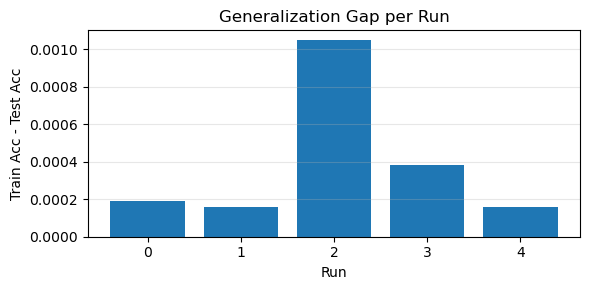

In [19]:
# ...existing code...
num_runs = 5
run_records = []

for seed in range(num_runs):
    X_train, X_test, y_train_run, y_test = train_test_split(
        X_scaled,
        y,
        test_size=best_params_final['split'],
        random_state=seed,
        stratify=y if target_type == 'classification' else None
    )

    y_train = y_train_run
    model = create_dnn_model(
        input_dim=X_train.shape[1],
        hidden_layers=best_params_final['hidden_layers'],
        activation=best_params_final['activation'],
        learning_rate=best_params_final['learning_rate'],
        target_type=target_type
    )

    history_obj = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=best_params_final['epochs'],
        batch_size=best_params_final['batch_size'],
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    )
    history = history_obj.history
    val_acc_last = history.get('val_accuracy', [None])[-1]

    train_pred = model.predict(X_train, verbose=0)
    test_pred = model.predict(X_test, verbose=0)

    if len(np.unique(y_train)) == 2:
        train_label = (train_pred.ravel() >= 0.5).astype(int)
        test_label = (test_pred.ravel() >= 0.5).astype(int)
    else:
        train_label = np.argmax(train_pred, axis=1)
        test_label = np.argmax(test_pred, axis=1)

    train_acc = accuracy_score(y_train, train_label)
    test_acc = accuracy_score(y_test, test_label)

    run_records.append({
        'run': seed,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc_last,
        'test_accuracy': test_acc,
        'generalization_gap': train_acc - test_acc
    })

df_overfit = pd.DataFrame(run_records)
display(df_overfit)

plt.figure(figsize=(6, 3))
plt.bar(df_overfit['run'], df_overfit['generalization_gap'])
plt.title('Generalization Gap per Run')
plt.xlabel('Run')
plt.ylabel('Train Acc - Test Acc')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# ...existing code...

In [20]:
with open('hasil_optimasi.json', 'w') as f:
    json.dump(results_log, f, indent=2)

# Menyimpan model final dari batch terakhir (batch_size)
final_model = best_models.get(batch_order[-1], None)
if final_model:
    final_model.save('model_terbaik.h5')
    print("Model terbaik disimpan sebagai model_terbaik.h5")

Model terbaik disimpan sebagai model_terbaik.h5
